# 10.5 LightGBM算法案例实战1 - 客户违约预测模型

In [2]:
# 1.读取数据
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第10章 机器学习神器：XGBoost&LightGBM模型\源代码汇总_Jupyer Notebook\客户信息及违约表现.xlsx")
df.head()

,收入,年龄,性别,历史授信额度,历史违约次数,是否违约
0,462087,26,1,0,1,1
1,362324,32,0,13583,0,1
2,332011,52,1,0,1,1
3,252895,39,0,0,1,1
4,352355,50,1,0,0,1


In [4]:
# 2.提取特征变量和目标变量
X = df.drop(columns='是否违约')
Y = df['是否违约']

# 3.划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=123)

## 随机森林模型

In [7]:
#模型搭建
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=123)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

随机森林准确率: 0.845


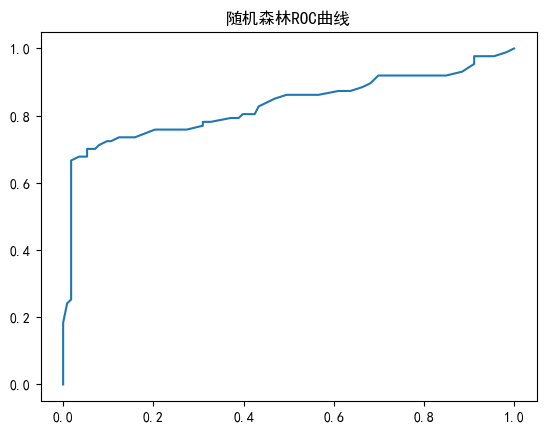

随机森林AUC: 0.8301800427220019


,特征名称,特征重要性
0,收入,0.387979
4,历史违约次数,0.244462
3,历史授信额度,0.220230
1,年龄,0.128917
2,性别,0.018412


In [11]:
#模型预测及评估
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

y_pred_rf = model_rf.predict(X_test)

# 准确率
from sklearn.metrics import accuracy_score
score_rf = accuracy_score(y_pred_rf, y_test)
print("随机森林准确率:", score_rf)

# ROC曲线和AUC
y_pred_proba_rf = model_rf.predict_proba(X_test)
from sklearn.metrics import roc_curve, roc_auc_score
fpr_rf, tpr_rf, thres_rf = roc_curve(y_test, y_pred_proba_rf[:,1])

import matplotlib.pyplot as plt
plt.plot(fpr_rf, tpr_rf)
plt.title('随机森林ROC曲线')
plt.show()

auc_rf = roc_auc_score(y_test, y_pred_proba_rf[:,1])
print("随机森林AUC:", auc_rf)

# 特征重要性
features = X.columns
importances_rf = model_rf.feature_importances_
importances_df_rf = pd.DataFrame()
importances_df_rf['特征名称'] = features
importances_df_rf['特征重要性'] = importances_rf
importances_df_rf.sort_values('特征重要性', ascending=False)

## 逻辑回归模型

In [14]:
#模型搭建
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=123)
model_lr.fit(X_train, y_train)

LogisticRegression(random_state=123)

逻辑回归准确率: 0.745


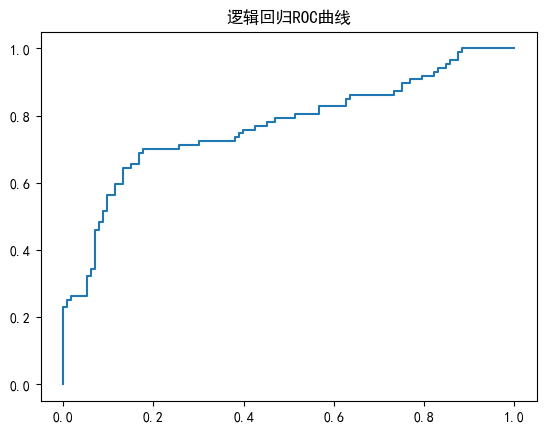

逻辑回归AUC: 0.7693011901129081


In [16]:
#模型预测及评估
y_pred_lr = model_lr.predict(X_test)

# 准确率
score_lr = accuracy_score(y_pred_lr, y_test)
print("逻辑回归准确率:", score_lr)

# ROC曲线和AUC
y_pred_proba_lr = model_lr.predict_proba(X_test)
fpr_lr, tpr_lr, thres_lr = roc_curve(y_test, y_pred_proba_lr[:,1])

plt.plot(fpr_lr, tpr_lr)
plt.title('逻辑回归ROC曲线')
plt.show()

auc_lr = roc_auc_score(y_test, y_pred_proba_lr[:,1])
print("逻辑回归AUC:", auc_lr)

## XGBoost模型

In [19]:
#模型搭建
from xgboost import XGBClassifier
model_xgb = XGBClassifier(random_state=123)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

XGBoost准确率: 0.77


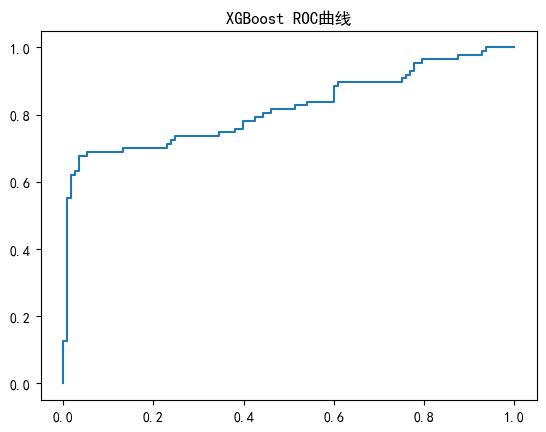

XGBoost AUC: 0.8183297731665141


,特征名称,特征重要性
4,历史违约次数,0.674848
0,收入,0.116233
3,历史授信额度,0.098104
1,年龄,0.055755
2,性别,0.055060


In [24]:
#模型预测及评估
y_pred_xgb = model_xgb.predict(X_test)

# 准确率
score_xgb = accuracy_score(y_pred_xgb, y_test)
print("XGBoost准确率:", score_xgb)

# ROC曲线和AUC
y_pred_proba_xgb = model_xgb.predict_proba(X_test)
fpr_xgb, tpr_xgb, thres_xgb = roc_curve(y_test, y_pred_proba_xgb[:,1])

plt.plot(fpr_xgb, tpr_xgb)
plt.title('XGBoost ROC曲线')
plt.show()

auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb[:,1])
print("XGBoost AUC:", auc_xgb)

# 特征重要性
importances_xgb = model_xgb.feature_importances_
importances_df_xgb = pd.DataFrame()
importances_df_xgb['特征名称'] = features
importances_df_xgb['特征重要性'] = importances_xgb
importances_df_xgb.sort_values('特征重要性', ascending=False)